# [WIP] Proposed Redesign of SB-MOABB DataIO


In [1]:
%load_ext line_profiler
%load_ext memory_profiler

In [2]:
%%capture
!pip install speechbrain moabb mne mne_bids braindecode

# Extend DynamicItemDataset to support BIDS and MOABB datasets


In [1]:
import logging
import os
from functools import cache

import mne
import moabb
import numpy as np
import torch
from dataio.datasets import EpochedEEGDataset, RawEEGDataset, InMemoryDataset
from moabb.datasets import BNCI2014_001

from speechbrain.utils.data_pipeline import provides, takes

mne.set_log_level(verbose=False)
moabb.set_log_level(level="ERROR")

/home/radicalshadow/Projects/Research/benchmarks/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
%%memit
dataset = EpochedEEGDataset.from_moabb(
    BNCI2014_001(),
    "data/MNE-BIDS-bnci2014-001-epoched.json",
    save_path="data",
    tmin=0,
    tmax=4.0,
    output_keys=[
        "label",
        "subject",
        "session",
        "epoch",
    ],
)

for _ in dataset:
    pass


peak memory: 777.96 MiB, increment: 42.67 MiB


In [5]:
%%time
for _ in dataset:
    pass

CPU times: user 1.75 s, sys: 110 ms, total: 1.86 s
Wall time: 1.86 s


In [6]:
%%memit
from braindecode.datasets import MOABBDataset
from braindecode.preprocessing import create_windows_from_events

raw_braindecode_dataset = MOABBDataset("BNCI2014_001", subject_ids=None)
epoched_braindecode_dataset = create_windows_from_events(raw_braindecode_dataset)

for sample in epoched_braindecode_dataset:
    pass

peak memory: 2963.88 MiB, increment: 2185.91 MiB


In [7]:
%%timeit

for sample in epoched_braindecode_dataset:
    pass

170 ms ± 4.28 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [8]:
%%memit
dataset = EpochedEEGDataset.from_moabb(
    BNCI2014_001(),
    "data/MNE-BIDS-bnci2014-001-epoched.json",
    save_path="data",
    tmin=0,
    tmax=4.0,
    output_keys=[
        "label",
        "subject",
        "session",
        "epoch",
    ],
    preload=True
)

for _ in dataset:
    pass


peak memory: 4621.82 MiB, increment: 1779.12 MiB


In [9]:
%%timeit
for _ in dataset:
    pass

165 ms ± 3.15 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [10]:
print(dataset[0]["epoch"].shape, epoched_braindecode_dataset[0][0].shape)
np.allclose(dataset[0]["epoch"], epoched_braindecode_dataset[0][0][:22])

(22, 1000) (26, 1000)


True

In [5]:
hparams = dict(target_sampling_frequency=125, fmin=None, fmax=22)


@takes("epoch")
@provides("epoch")
def to_tensor(epoch):
    return torch.from_numpy(epoch).float()


# Wrap `create_filter` in a cache so that expensive filters
# will only be created once.
cached_create_filter = cache(mne.filter.create_filter)


@takes("epoch", "info")
@provides("epoch", "sfreq")
def bandpass_resample(epoch, info):
    bandpass = cached_create_filter(
        None,  # can't pass epoch (ndarray) if we want to cache the filters
        info["sfreq"],
        l_freq=hparams["fmin"],
        h_freq=hparams["fmax"],
        method="fir",
        fir_design="firwin",
        verbose=False,
    )

    # Check that filter length is reasonable
    filter_length = len(bandpass)
    len_x = epoch.shape[-1]
    if filter_length > len_x:
        # TODO: These long filters result in massive performance degradation... Do we
        #       want to throw an error instead? This usually happens when fmin is used
        logging.warning(
            "filter_length (%i) is longer than the signal (%i), "
            "distortion is likely. Reduce filter length or filter a longer signal.",
            filter_length,
            len_x,
        )

    yield mne.filter.resample(
        epoch,
        up=hparams["target_sampling_frequency"],
        down=info["sfreq"],
        method="polyphase",
        window=bandpass,
    )
    yield hparams["target_sampling_frequency"]


dataset = EpochedEEGDataset.from_moabb(
    BNCI2014_001(),
    "data/MNE-BIDS-bnci2014-001-epoched.json",
    save_path="data",
    tmin=0,
    tmax=4.0,
    output_keys=["label", "subject", "session", "epoch", "sfreq"],
    dynamic_items=[bandpass_resample, to_tensor],
    preload=False,
)
# Wrap the DynamicItemDataset so that computed items are cached in memory
dataset = InMemoryDataset(dataset)
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=64, num_workers=os.cpu_count(), persistent_workers=True
)
for _ in dataloader:
    pass

In [6]:
%%timeit
for _ in dataloader:
    pass

75.9 ms ± 376 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Visualize A Sample

In [16]:
sample = dataset[0]
sample

{'label': 'tongue',
 'subject': '1',
 'session': '0train',
 'epoch': tensor([[ 9.3148e-06,  5.9836e-06, -1.3001e-06,  ...,  3.3904e-06,
          -1.1392e-06, -5.2451e-06],
         [-1.3243e-07, -2.2629e-06, -6.5100e-06,  ...,  5.4944e-06,
           2.5552e-06, -6.2729e-07],
         [ 3.7427e-06,  1.0976e-06, -4.6051e-06,  ...,  3.5345e-06,
          -7.0529e-07, -4.7742e-06],
         ...,
         [-5.6592e-06, -6.1603e-06, -6.7757e-06,  ...,  3.2320e-06,
           8.4109e-07, -2.5656e-06],
         [-6.8800e-06, -6.8522e-06, -6.4357e-06,  ...,  4.8161e-06,
           2.0939e-06, -1.4730e-06],
         [-3.5984e-06, -3.7302e-06, -3.7411e-06,  ...,  7.6142e-07,
           9.0636e-07,  1.9678e-07]]),
 'sfreq': 125}

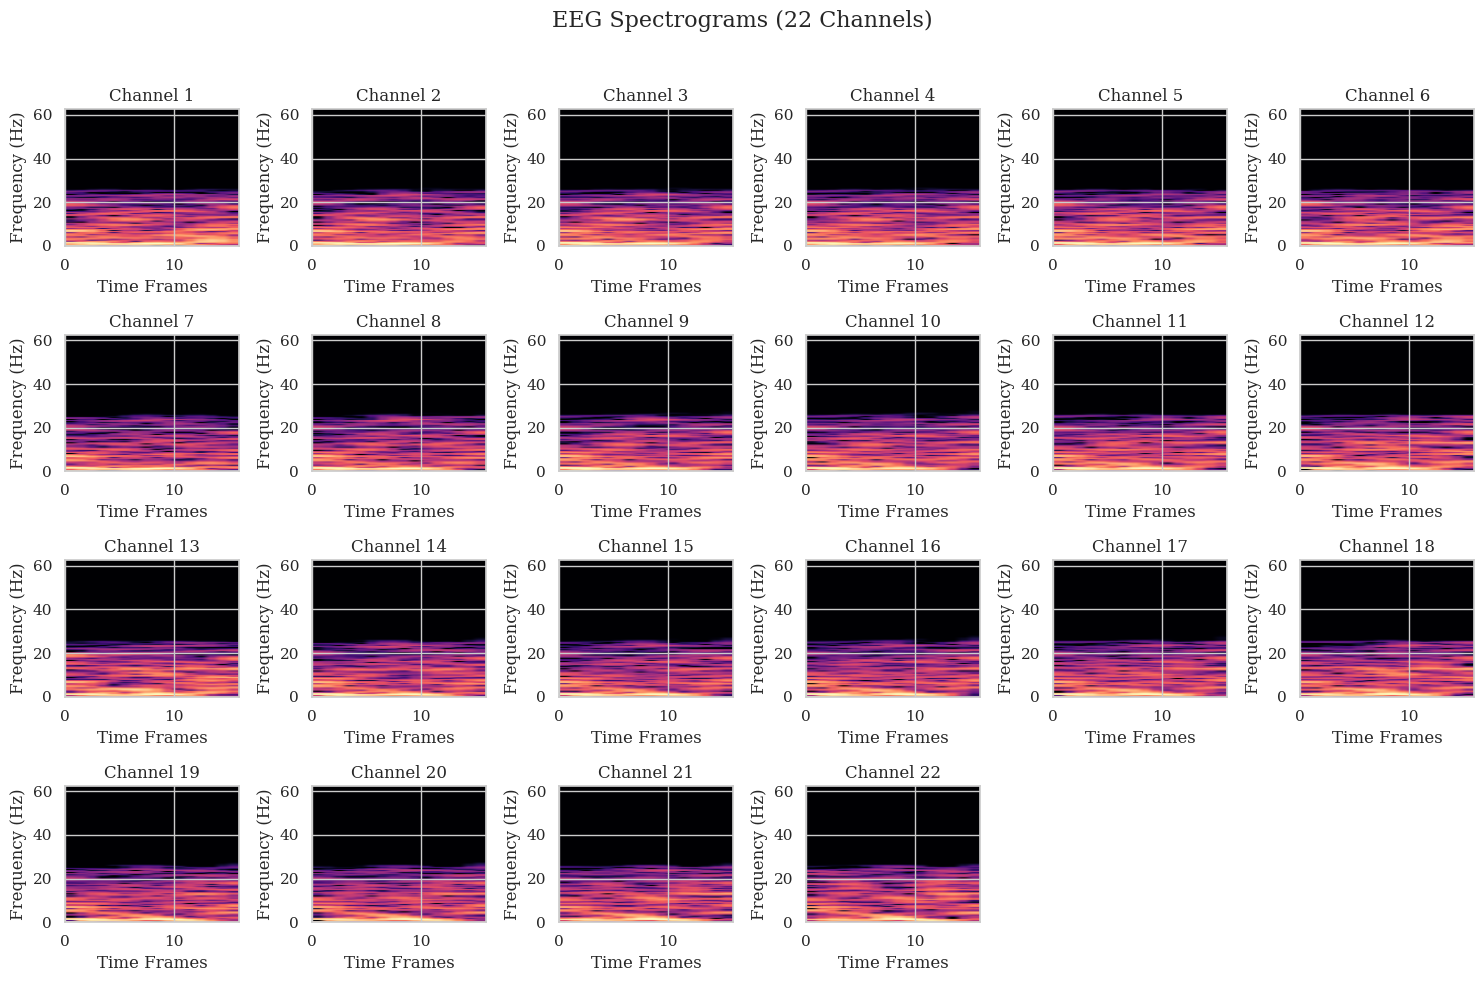

In [17]:
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt

# Example EEG signal (22 channels, 1000 samples)
n_fft=256
hop_length=32
fs = sample['sfreq']
num_channels = sample['epoch'].size(0)

# Spectrogram transform
spectrogram_transform = T.Spectrogram(n_fft=n_fft, hop_length=hop_length, power=2.0)

# Compute spectrograms for all channels
spectrograms = spectrogram_transform(sample['epoch'])  # Shape: (22, freq_bins, time_frames)
pass
# Convert to dB scale for better visualization
spectrograms_db = torchaudio.functional.amplitude_to_DB(spectrograms, multiplier=10.0, amin=1e-10, db_multiplier=0)

freqs = np.fft.rfftfreq(n_fft, d=1/fs)  # Convert frequency bins to real values

# Plot in a grid (e.g., 6 rows × 4 columns)
rows, cols = 4, 6
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
fig.suptitle("EEG Spectrograms (22 Channels)", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < num_channels:
        img = ax.imshow(spectrograms_db[i].numpy(), aspect="auto", origin="lower", cmap="magma",
                extent=[0, spectrograms_db.shape[2], freqs[0], freqs[-1]])  # Use extent to set frequency axis
        ax.set_title(f"Channel {i+1}")
        ax.set_xlabel("Time Frames")
        ax.set_ylabel("Frequency (Hz)")
    else:
        ax.axis("off")  # Hide unused subplots

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
